In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow_addons as tfa

c:\Users\Deepa\.conda\envs\tensorflow_env\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\Deepa\.conda\envs\tensorflow_env\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an 

In [19]:
training_dataset = image_dataset_from_directory(
    "./train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 76515 files belonging to 4 classes.


In [20]:
validating_dataset = image_dataset_from_directory(
    "./val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 21861 files belonging to 4 classes.


In [21]:
training_dataset

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [22]:
IMAGE_SHAPE = (224,224,3)

In [23]:
mobileNetV3 = tf.keras.applications.MobileNetV3Large(
    input_shape=IMAGE_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
)


In [24]:
# mobileNetV3.trainable = False
# This is used to freeze to trin the model as it is used when we have less dataset 

In [25]:
model = tf.keras.models.Sequential()

In [26]:
model.add(tf.keras.Input(shape=IMAGE_SHAPE))


In [27]:
model.add(mobileNetV3)

In [28]:
model.add(tf.keras.layers.Dense(units=4 , activation="softmax"))

In [ ]:
# def f1_score(y_true, y_pred):
#     precision = tf.keras.metrics.Precision()(y_true, y_pred)
#     recall = tf.keras.metrics.Recall()(y_true, y_pred)
#     return 2*((precision*recall)/(precision+recall+1e-7))
# metrix_list = ["accuracy" ,f1_score]

In [46]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001) , loss="categorical_crossentropy" , metrics=[
        "accuracy",
        tfa.metrics.F1Score(num_classes=4, average="macro")
    ])

In [48]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense_1 (Dense)             (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [49]:
training_history = model.fit(x=training_dataset , validation_data=validating_dataset ,epochs=15)

Epoch 1/15
2392/2392 [==============================] - 564s 230ms/step - loss: 1.1252 - accuracy: 0.8809 - f1_score: 0.6909 - val_loss: 0.9524 - val_accuracy: 0.8986 - val_f1_score: 0.6957
Epoch 2/15
2392/2392 [==============================] - 618s 258ms/step - loss: 0.8224 - accuracy: 0.9144 - f1_score: 0.7941 - val_loss: 0.7150 - val_accuracy: 0.9445 - val_f1_score: 0.9032
Epoch 3/15
2392/2392 [==============================] - 544s 227ms/step - loss: 0.6206 - accuracy: 0.9540 - f1_score: 0.9201 - val_loss: 0.5471 - val_accuracy: 0.9577 - val_f1_score: 0.9237
Epoch 4/15
2392/2392 [==============================] - 543s 227ms/step - loss: 0.4769 - accuracy: 0.9601 - f1_score: 0.9311 - val_loss: 0.4247 - val_accuracy: 0.9625 - val_f1_score: 0.9335
Epoch 5/15
2392/2392 [==============================] - 539s 225ms/step - loss: 0.3720 - accuracy: 0.9644 - f1_score: 0.9388 - val_loss: 0.3413 - val_accuracy: 0.9599 - val_f1_score: 0.9296
Epoch 6/15
2392/2392 [============================

In [50]:
model.save("./trained_model.h5")

In [56]:
training_history.history

{'loss': [1.1252237558364868,
  0.8223779201507568,
  0.6205974817276001,
  0.47689738869667053,
  0.37199127674102783,
  0.2901860177516937,
  0.2269621044397354,
  0.1795002818107605,
  0.1444300264120102,
  0.11871446669101715,
  0.09769362956285477,
  0.08297693729400635,
  0.07061499357223511,
  0.06302786618471146,
  0.05786486715078354],
 'accuracy': [0.88089919090271,
  0.9143958687782288,
  0.9539567232131958,
  0.9601385593414307,
  0.9643991589546204,
  0.9683199524879456,
  0.9735868573188782,
  0.9773508310317993,
  0.9809972047805786,
  0.9832451343536377,
  0.9856237173080444,
  0.9869959950447083,
  0.988681972026825,
  0.9897405505180359,
  0.9903678894042969],
 'f1_score': [0.6909498572349548,
  0.7940568327903748,
  0.9201415777206421,
  0.9310760498046875,
  0.9387521147727966,
  0.9453625679016113,
  0.9542017579078674,
  0.9606106281280518,
  0.9670564532279968,
  0.9710440635681152,
  0.9748642444610596,
  0.9773950576782227,
  0.9802232980728149,
  0.98232722282

In [55]:
import pickle
with open("Training_history01.pkl" , "wb") as f:
    pickle.dump(training_history.history ,f)

In [6]:
import pickle
with open("Training_history01.pkl" , "rb") as f:
    load_history = pickle.load(f)
print(load_history)
print(load_history.keys())

{'loss': [1.1252237558364868, 0.8223779201507568, 0.6205974817276001, 0.47689738869667053, 0.37199127674102783, 0.2901860177516937, 0.2269621044397354, 0.1795002818107605, 0.1444300264120102, 0.11871446669101715, 0.09769362956285477, 0.08297693729400635, 0.07061499357223511, 0.06302786618471146, 0.05786486715078354], 'accuracy': [0.88089919090271, 0.9143958687782288, 0.9539567232131958, 0.9601385593414307, 0.9643991589546204, 0.9683199524879456, 0.9735868573188782, 0.9773508310317993, 0.9809972047805786, 0.9832451343536377, 0.9856237173080444, 0.9869959950447083, 0.988681972026825, 0.9897405505180359, 0.9903678894042969], 'f1_score': [0.6909498572349548, 0.7940568327903748, 0.9201415777206421, 0.9310760498046875, 0.9387521147727966, 0.9453625679016113, 0.9542017579078674, 0.9606106281280518, 0.9670564532279968, 0.9710440635681152, 0.9748642444610596, 0.9773950576782227, 0.9802232980728149, 0.9823272228240967, 0.9832519888877869], 'val_loss': [0.9524258971214294, 0.7149686217308044, 0.5

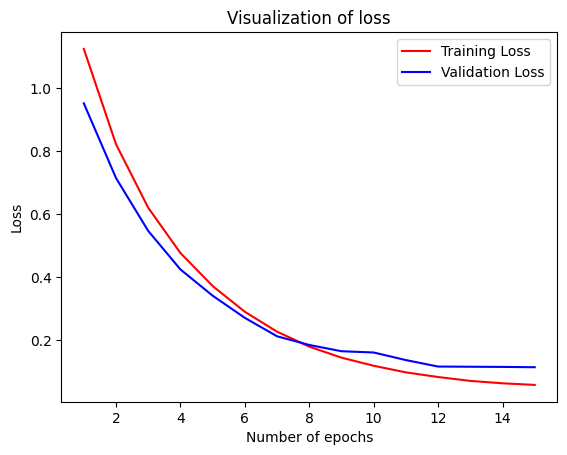

In [7]:
# Loss visizuilizzation
epochs = [i for i in range(1,16)]
plt.plot(epochs , load_history['loss'] , color='red' , label='Training Loss')
plt.plot(epochs , load_history['val_loss'] , color='blue' , label='Validation Loss')
plt.xlabel("Number of epochs")
plt.ylabel("Loss")
plt.title("Visualization of loss")
plt.legend()
plt.show()

In [2]:
model= tf.keras.models.load_model("trained_model.h5")

In [22]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense_1 (Dense)             (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [23]:
# checking on test data
testing_dataset = image_dataset_from_directory(
    "./test",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10933 files belonging to 4 classes.


In [12]:
test_loss , test_acc , f1_score = model.evaluate(testing_dataset)

342/342 [==============================] - 24s 48ms/step - loss: 0.1238 - accuracy: 0.9723 - f1_score: 0.9510


In [14]:
y_pred = model.predict(testing_dataset)



342/342 [==============================] - 17s 46ms/step


In [15]:
y_pred = y_pred.argmax(axis=1)
y_pred

array([0, 0, 0, ..., 3, 3, 3], dtype=int64)

In [ ]:
test_loss , test_acc , f1_score 

(0.12377897650003433, 0.9722857475280762, 0.9510495662689209)

In [13]:
# Here are the true labels 
true_categories = tf.concat([y for x,y in testing_dataset] , axis=0)
y_true = tf.argmax(true_categories , axis=1)
y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_true , y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3746
           1       0.97      0.95      0.96      1161
           2       0.92      0.85      0.88       887
           3       0.98      0.99      0.99      5139

    accuracy                           0.97     10933
   macro avg       0.96      0.94      0.95     10933
weighted avg       0.97      0.97      0.97     10933



In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true,y_pred)
cm

array([[3678,   12,   49,    7],
       [  22, 1098,    3,   38],
       [  72,    5,  756,   54],
       [   5,   18,   18, 5098]], dtype=int64)

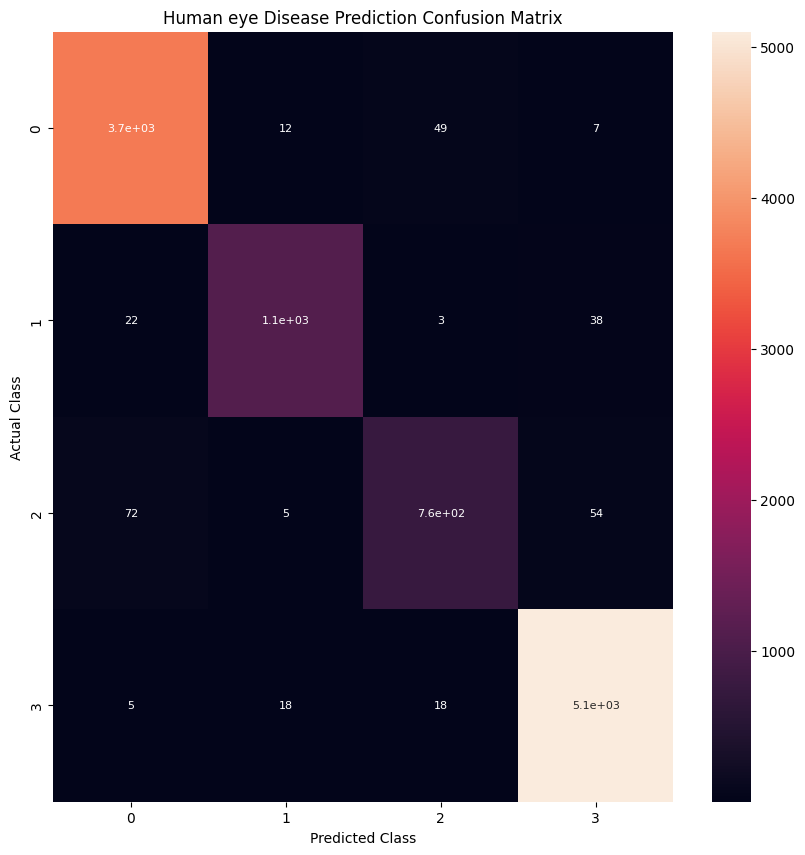

In [20]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot= True , annot_kws={"size": 8})
plt.xlabel("Predicted Class" , fontsize=10)
plt.ylabel("Actual Class" , fontsize=10)
plt.title("Human eye Disease Prediction Confusion Matrix" , fontsize=12)
plt.show()
